In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))
tf.config.optimizer.set_jit(True)  # XLA hızlandırma

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kagglehub

import numpy as np
import matplotlib.pyplot as plt
import os, time, shutil, subprocess
from PIL import Image
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("✅ Import'lar tamam. TF versiyonu:", tf.__version__)

✅ Import'lar tamam. TF versiyonu: 2.20.0


In [ ]:
dataset_dir = "/content/dataset"
if not os.path.exists(dataset_dir) or not os.listdir(dataset_dir):
    print("Veri indiriliyor...")
    path = kagglehub.dataset_download("prithivsakthiur/deepfake-vs-real-20k")
    !cp -r {path} /content/dataset
    print("İndirme tamam.")
else:
    print("Veri seti mevcut.")

root = "/content/dataset"
contents = os.listdir(root)
if len(contents) == 1 and os.path.isdir(os.path.join(root, contents[0])):
    base_dir = os.path.join(root, contents[0])
else:
    base_dir = root
print("Veri klasörü:", base_dir)
print("İçerik:", os.listdir(base_dir))

Veri indiriliyor...


100%|██████████| 10.9G/10.9G [04:55<00:00, 39.7MB/s]

Extracting files...


İndirme tamam.
Veri klasörü: /content/dataset/Deep-vs-Real
İçerik: ['Deepfake', 'Real']


In [ ]:
split_base = "/content/split_data"

subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
real_dir_name = next(d for d in subdirs if 'real' in d.lower())
fake_dir_name = next(d for d in subdirs if d != real_dir_name)
print(f"Gerçek: {real_dir_name}, Sahte: {fake_dir_name}")

real_dir = os.path.join(base_dir, real_dir_name)
fake_dir = os.path.join(base_dir, fake_dir_name)

valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
real_files = sorted([f for f in os.listdir(real_dir) if f.lower().endswith(valid_exts)])
fake_files = sorted([f for f in os.listdir(fake_dir) if f.lower().endswith(valid_exts)])
print(f"Real: {len(real_files)}, Fake: {len(fake_files)}")

# Sınıf dengesi raporu (SCRUM-7)
total = len(real_files) + len(fake_files)
print(f"\n📊 Sınıf Dengesi:")
print(f"  Real : {len(real_files)} ({len(real_files)/total*100:.1f}%)")
print(f"  Fake : {len(fake_files)} ({len(fake_files)/total*100:.1f}%)")

all_files  = [os.path.join(real_dir, f) for f in real_files] + \
             [os.path.join(fake_dir, f) for f in fake_files]
all_labels = [0]*len(real_files) + [1]*len(fake_files)

# %80 Train, %10 Val, %10 Test
train_f, temp_f, train_l, temp_l = train_test_split(
    all_files, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_f, test_f, val_l, test_l = train_test_split(
    temp_f, temp_l, test_size=0.5, random_state=42, stratify=temp_l)

print(f"\n✅ Split: Train={len(train_f)}, Val={len(val_f)}, Test={len(test_f)}")

if os.path.exists(split_base):
    shutil.rmtree(split_base)
for split in ['train', 'val', 'test']:
    for cls in [real_dir_name, fake_dir_name]:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)
print("Bölme planı hazır.")

Gerçek: Real, Sahte: Deepfake
Real: 9643, Fake: 9576

📊 Sınıf Dengesi:
  Real : 9643 (50.2%)
  Fake : 9576 (49.8%)

✅ Split: Train=15375, Val=1922, Test=1922
Bölme planı hazır.


In [ ]:
from tqdm.notebook import tqdm

required_dirs = [os.path.join(split_base, s, c)
                 for s in ['train','val','test']
                 for c in [real_dir_name, fake_dir_name]]

if all(os.path.exists(d) and len(os.listdir(d)) > 0 for d in required_dirs):
    print("✅ Bölünmüş veri zaten mevcut, kopyalama atlanıyor.")
    for split in ['train', 'val', 'test']:
        for cls in [real_dir_name, fake_dir_name]:
            d = os.path.join(split_base, split, cls)
            print(f"  {split}/{cls}: {len(os.listdir(d))} dosya")
else:
    def copy_resize(file_list, label_list, split, desc):
        for i, (src, label) in tqdm(enumerate(zip(file_list, label_list)),
                                     total=len(file_list), desc=desc):
            cls = real_dir_name if label == 0 else fake_dir_name
            dst = os.path.join(split_base, split, cls, f"{i:06d}.jpg")
            img = Image.open(src).convert('RGB')
            img = img.resize((224, 224), Image.Resampling.LANCZOS)
            img.save(dst, 'JPEG')

    copy_resize(train_f, train_l, 'train', 'Train')
    copy_resize(val_f,   val_l,   'val',   'Val')
    copy_resize(test_f,  test_l,  'test',  'Test')

    for split in ['train', 'val', 'test']:
        for cls in [real_dir_name, fake_dir_name]:
            d = os.path.join(split_base, split, cls)
            print(f"  {split}/{cls}: {len(os.listdir(d))} dosya")
    print("✅ Kopyalama ve 224x224 boyutlandırma tamamlandı.")

Train:   0%|          | 0/15375 [00:00<?, ?it/s]

Val:   0%|          | 0/1922 [00:00<?, ?it/s]

Test:   0%|          | 0/1922 [00:00<?, ?it/s]

  train/Real: 7714 dosya
  train/Deepfake: 7661 dosya
  val/Real: 965 dosya
  val/Deepfake: 957 dosya
  test/Real: 964 dosya
  test/Deepfake: 958 dosya
✅ Kopyalama ve 224x224 boyutlandırma tamamlandı.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import os

# ── Runtime yeniden başladıysa kurtar ──────────────────────────────
split_base = "/content/split_data"
base_dir   = "/content/dataset"
_c = os.listdir(base_dir)
if len(_c) == 1 and os.path.isdir(os.path.join(base_dir, _c[0])):
    base_dir = os.path.join(base_dir, _c[0])
_s = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
real_dir_name = next(d for d in _s if 'real' in d.lower())
fake_dir_name = next(d for d in _s if d != real_dir_name)
print(f"✅ Sınıflar → Real: '{real_dir_name}', Fake: '{fake_dir_name}'")
# ───────────────────────────────────────────────────────────────────

img_size    = (224, 224)
batch_size  = 32
class_names = [real_dir_name, fake_dir_name]
AUTOTUNE    = tf.data.AUTOTUNE

def make_raw_dataset(path, shuffle=False):
    return tf.keras.utils.image_dataset_from_directory(
        path,
        labels='inferred',
        label_mode='binary',
        class_names=class_names,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

train_ds_raw = make_raw_dataset(f"{split_base}/train", shuffle=True)
val_ds_raw   = make_raw_dataset(f"{split_base}/val")
test_ds_raw  = make_raw_dataset(f"{split_base}/test")

# Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def augment(img, label):
    return data_aug(img, training=True), label

# ✅ Cache → Augment → Prefetch sırası
train_ds_raw = train_ds_raw.cache().map(augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_raw   = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds_raw  = test_ds_raw.prefetch(AUTOTUNE)

# Sonuç takip dict'i
results = {}

print("✅ Pipeline hazır. Sınıf sırası:", class_names)

✅ Sınıflar → Real: 'Real', Fake: 'Deepfake'
Found 15375 files belonging to 2 classes.
Found 1922 files belonging to 2 classes.
Found 1922 files belonging to 2 classes.
✅ Pipeline hazır. Sınıf sırası: ['Real', 'Deepfake']


In [ ]:
tf.keras.backend.clear_session()

def get_gpu_memory():
    try:
        out = subprocess.run(
            ['nvidia-smi','--query-gpu=memory.used,memory.total',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True).stdout.strip()
        used, total = map(int, out.split(', '))
        return used, total
    except:
        return 0, 0

# Xception preprocessing: [0,255] → [-1, 1]
xception_preprocess = layers.Lambda(
    lambda x: tf.keras.applications.xception.preprocess_input(x),
    name="xception_preprocess"
)

base_x = applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_x.trainable = False

x_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),     # ✅ Input katmanı eklendi
    xception_preprocess,
    base_x,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name="Xception_DeepfakeDetector")

x_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

total_params = x_model.count_params()
trainable    = sum([tf.size(w).numpy() for w in x_model.trainable_weights])
print(f"✅ Xception kuruldu")
print(f"   Toplam parametre    : {total_params:,}")
print(f"   Eğitilebilir param. : {trainable:,}")
x_model.summary(line_length=80)

✅ Xception kuruldu
   Toplam parametre    : 21,123,881
   Eğitilebilir param. : 262,401


Model: "Xception_DeepfakeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception_preprocess (Lambda)      │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ xception (Functional)             │ (None, 7, 7, 2048)       │    20,861,480 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 128)              │       262,272 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 1)                │           129 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

🚀 Xception eğitimi başlıyor...
Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8495 - loss: 0.3557
Epoch 1: val_accuracy improved from None to 0.94849, saving model to best_xception.keras

Epoch 1: finished saving model to best_xception.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 107s 159ms/step - accuracy: 0.9025 - loss: 0.2515 - val_accuracy: 0.9485 - val_loss: 0.1260 - learning_rate: 1.0000e-04
Epoch 2/15
480/481 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9357 - loss: 0.1685
Epoch 2: val_accuracy improved from 0.94849 to 0.95682, saving model to best_xception.keras

Epoch 2: finished saving model to best_xception.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9391 - loss: 0.1574 - val_accuracy: 0.9568 - val_loss: 0.1100 - learning_rate: 1.0000e-04
Epoch 3/15
480/481 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9423 - loss: 0.1481
Epoch 3: val_accuracy improved from 0.95682 to 0.95734, saving model to best_xception.keras

Epoch 3: finished saving mo

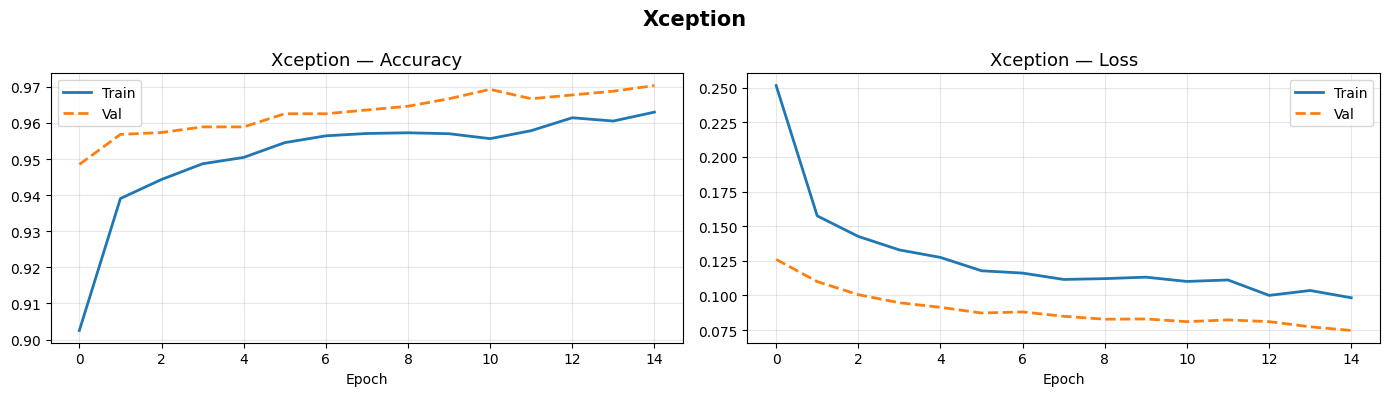


📈 En iyi Val Accuracy : 0.9703
⏱  Eğitim süresi       : 8.9 dk
🖥  GPU bellek kullanımı: ~16182 MB


In [ ]:
used_before, total_gpu = get_gpu_memory()

callbacks_x = [
    ModelCheckpoint("best_xception.keras",
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("🚀 Xception eğitimi başlıyor...")
start_x = time.time()
hist_x  = x_model.fit(
    train_ds_raw, epochs=15,
    validation_data=val_ds_raw,
    callbacks=callbacks_x,
    verbose=1
)
x_time = time.time() - start_x

used_after, _ = get_gpu_memory()
x_gpu_mb = used_after - used_before

# Log / plot
def plot_hist(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, label in zip(axes,
                                  [('accuracy','val_accuracy'),('loss','val_loss')],
                                  ['Accuracy','Loss']):
        ax.plot(hist.history[metric[0]], label='Train', linewidth=2)
        ax.plot(hist.history[metric[1]], label='Val',   linewidth=2, linestyle='--')
        ax.set_title(f'{title} — {label}', fontsize=13)
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_hist(hist_x, "Xception")

best_x_acc = max(hist_x.history['val_accuracy'])
print(f"\n📈 En iyi Val Accuracy : {best_x_acc:.4f}")
print(f"⏱  Eğitim süresi       : {x_time/60:.1f} dk")
print(f"🖥  GPU bellek kullanımı: ~{x_gpu_mb} MB")

# Kaydet
results['xception'] = {
    'best_val_acc': best_x_acc,
    'train_time_min': round(x_time/60, 2),
    'gpu_mb': x_gpu_mb,
    'params': x_model.count_params()
}

ℹ️  x_model yok, mimari yeniden kuruluyor...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Xception ağırlıkları yüklendi.


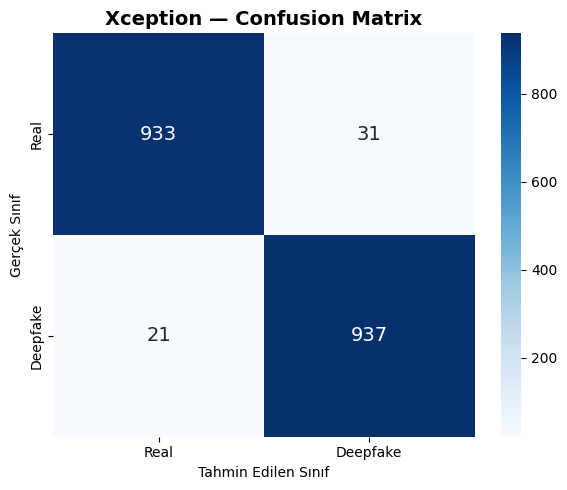

        XCEPTION — Classification Report
              precision    recall  f1-score   support

        Real     0.9780    0.9678    0.9729       964
    Deepfake     0.9680    0.9781    0.9730       958

    accuracy                         0.9729      1922
   macro avg     0.9730    0.9730    0.9729      1922
weighted avg     0.9730    0.9729    0.9729      1922

✅ Xception Test Accuracy: 0.9729


In [ ]:
# Model bellekte yoksa mimariyi yeniden kur
try:
    x_model
    print("ℹ️  x_model bellekte mevcut.")
except NameError:
    print("ℹ️  x_model yok, mimari yeniden kuruluyor...")
    xception_preprocess = layers.Lambda(
        lambda x: tf.keras.applications.xception.preprocess_input(x),
        name="xception_preprocess"
    )
    base_x = applications.Xception(
        weights='imagenet', include_top=False, input_shape=(224, 224, 3)
    )
    base_x.trainable = False

    x_model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        xception_preprocess,
        base_x,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name="Xception_DeepfakeDetector")

    x_model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='binary_crossentropy', metrics=['accuracy']
    )

# Sadece ağırlıkları yükle
x_model.load_weights("best_xception.keras")
print("✅ Xception ağırlıkları yüklendi.")

# Tahminler
y_true_x, y_pred_x = [], []
for imgs, labels in test_ds_raw:
    preds = x_model.predict(imgs, verbose=0)
    y_true_x.extend(labels.numpy().flatten().astype(int))
    y_pred_x.extend((preds.flatten() > 0.5).astype(int))

y_true_x = np.array(y_true_x)
y_pred_x = np.array(y_pred_x)

# Confusion Matrix
cm_x = confusion_matrix(y_true_x, y_pred_x)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_x, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Xception — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.tight_layout(); plt.show()

# Classification Report (4 haneli)
print("=" * 60)
print("        XCEPTION — Classification Report")
print("=" * 60)
print(classification_report(y_true_x, y_pred_x,
                             target_names=class_names, digits=4))

x_test_acc = np.mean(y_true_x == y_pred_x)
print(f"✅ Xception Test Accuracy: {x_test_acc:.4f}")

# results dict yoksa kur
if 'results' not in dir():
    results = {'xception': {}, 'efficientnet': {}}
elif 'xception' not in results:
    results['xception'] = {}

results['xception']['test_acc'] = round(float(x_test_acc), 4)

In [ ]:
# Xception'ı bellekten temizle (varsa)
try:
    del x_model
    print("🧹 x_model silindi.")
except NameError:
    print("ℹ️  x_model zaten yok, atlanıyor.")

tf.keras.backend.clear_session()
import gc; gc.collect()
print("🧹 GPU belleği temizlendi.")

# EfficientNetV2M — built-in preprocessing içerir, ham [0,255] besle
base_e = applications.EfficientNetV2M(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_e.trainable = False

e_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_e,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name="EfficientNetV2M_DeepfakeDetector")

e_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_e = sum([tf.size(w).numpy() for w in e_model.trainable_weights])
print(f"✅ EfficientNetV2M kuruldu")
print(f"   Toplam parametre    : {e_model.count_params():,}")
print(f"   Eğitilebilir param. : {trainable_e:,}")
e_model.summary(line_length=80)

ℹ️  x_model zaten yok, atlanıyor.
🧹 GPU belleği temizlendi.
✅ EfficientNetV2M kuruldu
   Toplam parametre    : 53,314,485
   Eğitilebilir param. : 164,097


Model: "EfficientNetV2M_DeepfakeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-m (Functional)     │ (None, 7, 7, 1280)       │    53,150,388 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 128)              │       163,968 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 1)                │           129 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 53,314,485 (203.38 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

🚀 EfficientNetV2M eğitimi başlıyor...
Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8361 - loss: 0.3925
Epoch 1: val_accuracy improved from None to 0.93600, saving model to best_efficientnetv2m.keras

Epoch 1: finished saving model to best_efficientnetv2m.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 202s 241ms/step - accuracy: 0.8926 - loss: 0.2823 - val_accuracy: 0.9360 - val_loss: 0.1722 - learning_rate: 1.0000e-04
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9304 - loss: 0.1822
Epoch 2: val_accuracy improved from 0.93600 to 0.94537, saving model to best_efficientnetv2m.keras

Epoch 2: finished saving model to best_efficientnetv2m.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - accuracy: 0.9352 - loss: 0.1704 - val_accuracy: 0.9454 - val_loss: 0.1346 - learning_rate: 1.0000e-04
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9421 - loss: 0.1529
Epoch 3: val_accuracy improved from 0.94537 to 0.95265, saving model to best_efficien

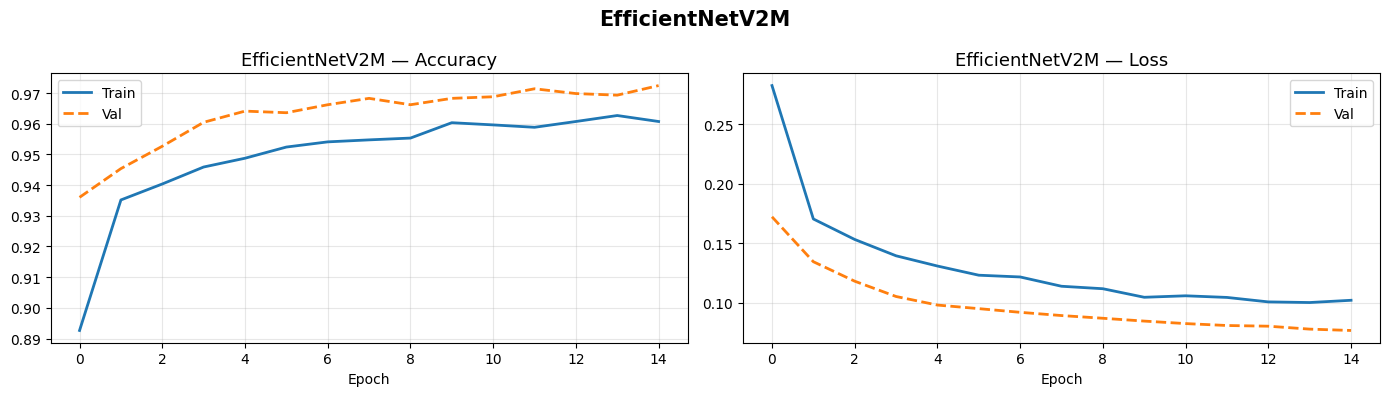


📈 En iyi Val Accuracy : 0.9724
⏱  Eğitim süresi       : 11.2 dk
🖥  GPU bellek kullanımı: ~14 MB


In [ ]:
used_before_e, _ = get_gpu_memory()

callbacks_e = [
    ModelCheckpoint("best_efficientnetv2m.keras",
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("🚀 EfficientNetV2M eğitimi başlıyor...")
start_e = time.time()
hist_e  = e_model.fit(
    train_ds_raw, epochs=15,
    validation_data=val_ds_raw,
    callbacks=callbacks_e,
    verbose=1
)
e_time = time.time() - start_e

used_after_e, _ = get_gpu_memory()
e_gpu_mb = used_after_e - used_before_e

plot_hist(hist_e, "EfficientNetV2M")

best_e_acc = max(hist_e.history['val_accuracy'])
print(f"\n📈 En iyi Val Accuracy : {best_e_acc:.4f}")
print(f"⏱  Eğitim süresi       : {e_time/60:.1f} dk")
print(f"🖥  GPU bellek kullanımı: ~{e_gpu_mb} MB")

results['efficientnet'] = {
    'best_val_acc': best_e_acc,
    'train_time_min': round(e_time/60, 2),
    'gpu_mb': e_gpu_mb,
    'params': e_model.count_params()
}

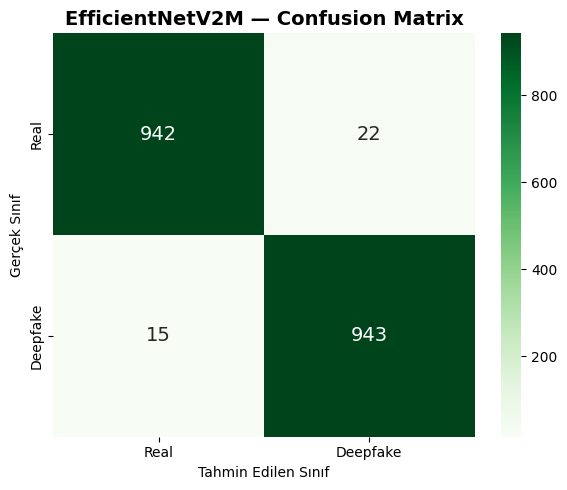

    EfficientNetV2M — Classification Report
              precision    recall  f1-score   support

        Real       0.98      0.98      0.98       964
    Deepfake       0.98      0.98      0.98       958

    accuracy                           0.98      1922
   macro avg       0.98      0.98      0.98      1922
weighted avg       0.98      0.98      0.98      1922

✅ EfficientNetV2M Test Accuracy: 0.9807


In [ ]:
e_model.load_weights("best_efficientnetv2m.keras")

y_true_e, y_pred_e = [], []
for imgs, labels in test_ds_raw:
    preds = e_model.predict(imgs, verbose=0)
    y_true_e.extend(labels.numpy().flatten().astype(int))
    y_pred_e.extend((preds.flatten() > 0.5).astype(int))

y_true_e = np.array(y_true_e)
y_pred_e = np.array(y_pred_e)

cm_e = confusion_matrix(y_true_e, y_pred_e)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('EfficientNetV2M — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.tight_layout(); plt.show()

print("=" * 55)
print("    EfficientNetV2M — Classification Report")
print("=" * 55)
print(classification_report(y_true_e, y_pred_e, target_names=class_names))

e_test_acc = np.mean(y_true_e == y_pred_e)
print(f"✅ EfficientNetV2M Test Accuracy: {e_test_acc:.4f}")

results['efficientnet']['test_acc'] = round(float(e_test_acc), 4)


        📊 MODEL KARŞILAŞTIRMA RAPORU
Metrik                                  Xception EfficientNetV2M
-----------------------------------------------------------------
En İyi Val Accuracy                       0.9703          0.9724
Test Accuracy                             0.9729          0.9807
Eğitim Süresi (dk)                           8.8            11.2
GPU Bellek Kullanımı (MB)                  16182              14
Toplam Parametre                      21,123,881      53,314,485

🏆 Önerilen Model: EfficientNetV2M
   Karar Gerekçesi:
   → EfficientNetV2M, Test Accuracy'de %0.78 daha başarılı.
   → Daha yüksek genelleme yeteneği gösterdi.


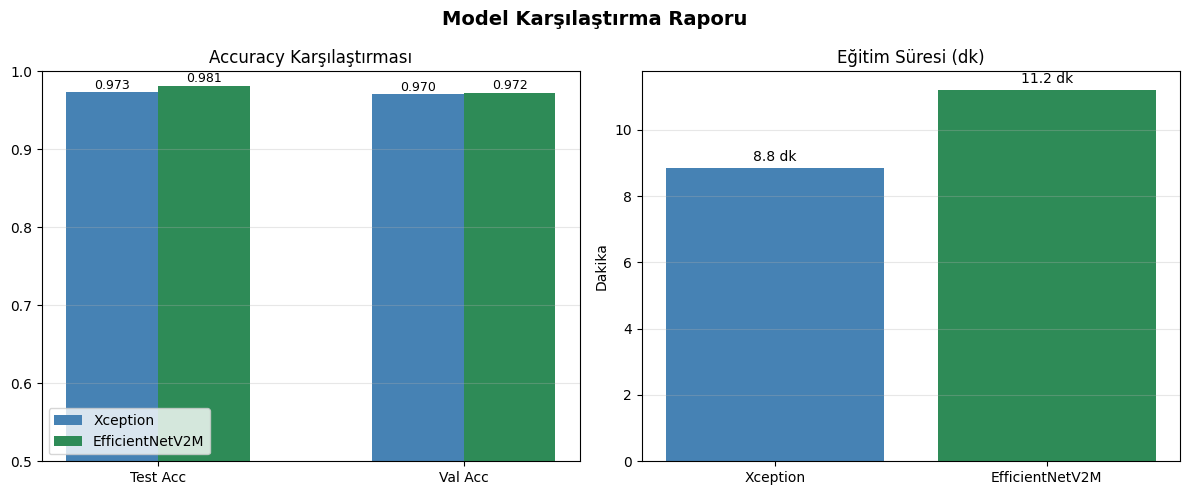


✅ Ağırlık dosyaları kaydedildi:
   → best_xception.keras
   → best_efficientnetv2m.keras


In [ ]:
rx = results['xception']
re = results['efficientnet']

print("\n" + "="*65)
print("        📊 MODEL KARŞILAŞTIRMA RAPORU")
print("="*65)
print(f"{'Metrik':<35} {'Xception':>12} {'EfficientNetV2M':>15}")
print("-"*65)
print(f"{'En İyi Val Accuracy':<35} {rx['best_val_acc']:>12.4f} {re['best_val_acc']:>15.4f}")
print(f"{'Test Accuracy':<35} {rx['test_acc']:>12.4f} {re['test_acc']:>15.4f}")
print(f"{'Eğitim Süresi (dk)':<35} {rx['train_time_min']:>12.1f} {re['train_time_min']:>15.1f}")
print(f"{'GPU Bellek Kullanımı (MB)':<35} {rx['gpu_mb']:>12} {re['gpu_mb']:>15}")
print(f"{'Toplam Parametre':<35} {rx['params']:>12,} {re['params']:>15,}")
print("="*65)

winner = "Xception" if rx['test_acc'] >= re['test_acc'] else "EfficientNetV2M"
print(f"\n🏆 Önerilen Model: {winner}")
print(f"   Karar Gerekçesi:")
if rx['test_acc'] >= re['test_acc']:
    diff = (rx['test_acc'] - re['test_acc'])*100
    print(f"   → Xception, Test Accuracy'de %{diff:.2f} daha başarılı.")
    print(f"   → Deepfake literatüründe (FaceForensics++) referans model.")
else:
    diff = (re['test_acc'] - rx['test_acc'])*100
    print(f"   → EfficientNetV2M, Test Accuracy'de %{diff:.2f} daha başarılı.")
    print(f"   → Daha yüksek genelleme yeteneği gösterdi.")

# Görsel karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics   = ['Test Acc', 'Val Acc']
x_vals    = [rx['test_acc'], rx['best_val_acc']]
e_vals    = [re['test_acc'], re['best_val_acc']]

x_pos = np.arange(len(metrics))
width = 0.3
axes[0].bar(x_pos - width/2, x_vals, width, label='Xception',       color='steelblue')
axes[0].bar(x_pos + width/2, e_vals, width, label='EfficientNetV2M', color='seagreen')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.0); axes[0].set_title('Accuracy Karşılaştırması')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, (xv, ev) in enumerate(zip(x_vals, e_vals)):
    axes[0].text(i - width/2, xv + 0.005, f'{xv:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, ev + 0.005, f'{ev:.3f}', ha='center', fontsize=9)

axes[1].bar(['Xception','EfficientNetV2M'],
            [rx['train_time_min'], re['train_time_min']],
            color=['steelblue','seagreen'])
axes[1].set_title('Eğitim Süresi (dk)')
axes[1].set_ylabel('Dakika'); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([rx['train_time_min'], re['train_time_min']]):
    axes[1].text(i, v + 0.2, f'{v:.1f} dk', ha='center', fontsize=10)

plt.suptitle('Model Karşılaştırma Raporu', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n✅ Ağırlık dosyaları kaydedildi:")
print("   → best_xception.keras")
print("   → best_efficientnetv2m.keras")